In [1]:
import pandas as pd

df = pd.read_csv("./perceptron_toydata-truncated.txt", sep="\t")

In [6]:
X_train = df[["x1", "x2"]].values
y_train = df["label"].values

In [7]:
X_train

array([[ 0.77, -1.14],
       [-0.33,  1.44],
       [ 0.91, -3.07],
       [-0.37, -1.91],
       [-0.63, -1.53],
       [ 0.39, -1.99],
       [-0.49, -2.74],
       [-0.68, -1.52],
       [-0.1 , -3.43],
       [-0.05, -1.95],
       [ 3.88,  0.65],
       [ 0.73,  2.97],
       [ 0.83,  3.94],
       [ 1.59,  1.25],
       [ 1.14,  3.91],
       [ 1.73,  2.8 ],
       [ 1.31,  1.85],
       [ 1.56,  3.85],
       [ 1.23,  2.54],
       [ 1.33,  2.03]])

In [8]:
y_train.shape

(20,)

In [9]:
import numpy as np

np.bincount(y_train)

array([10, 10])

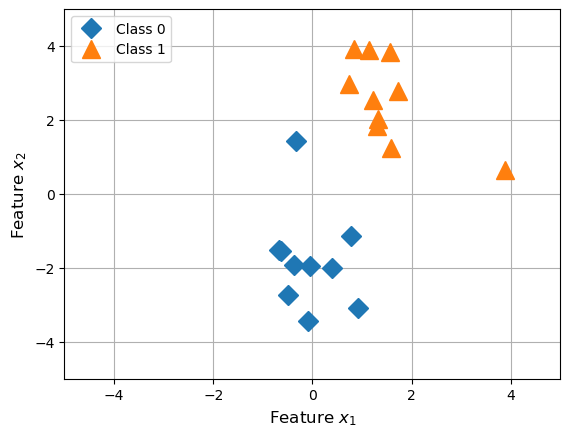

In [10]:
import matplotlib.pyplot as plt

plt.plot(
    X_train[y_train == 0, 0], # row x column
    X_train[y_train == 0, 1],
    marker="D",
    markersize=10,
    linestyle="",
    label="Class 0",
)

plt.plot(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    marker="^",
    markersize=13,
    linestyle="",
    label="Class 1",
)

plt.legend(loc=2)

plt.xlim([-5, 5])
plt.ylim([-5, 5])

plt.xlabel("Feature $x_1$", fontsize=12)
plt.ylabel("Feature $x_2$", fontsize=12)

plt.grid()
plt.show()

## Perceptron Model

### Net Input (z-value)
The **z-value** represents the net input to the perceptron, computed as the weighted sum of inputs plus bias.

### Decision Threshold
The perceptron makes binary classifications based on the z-value:
- If `z > 0` → Class 1
- If `z ≤ 0` → Class 0

### Model Parameters
- **Weights**: `w₁, w₂, ..., wₘ` - learned from training data
- **Bias**: `b` - shifts the decision boundary

### Computing the Net Input
The z-value is calculated as:

z = w₁x₁ + w₂x₂ + b


Or more generally:
z = b + Σᵢ₌₁ᵐ (wᵢ × xᵢ)

Where:
- `xᵢ` = input features
- `wᵢ` = corresponding weights
- `b` = bias term
- `m` = number of features

In [11]:
class Perceptron:
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = [0.0 for _ in range(num_features)]
        self.bias = 0.0

    def forward(self, x):
        weighted_sum_z = self.bias
        for i, _ in enumerate(self.weights):
            weighted_sum_z += x[i] * self.weights[i]

        if weighted_sum_z > 0.0:
            prediction = 1
        else:
            prediction = 0
        return prediction
    
    def update(self, x, true_y):
        prediction = self.forward(x)
        error = true_y - prediction

        # update
        self.bias += error
        for i, _ in enumerate(self.weights):
            self.weights[i] += error * x[i]

        return error

In [12]:
ppn = Perceptron(2)

x = [1.1, 2.1]
ppn.update(x, true_y=1)

1

In [13]:
def train(model, all_x, all_y, epochs):

    for epoch in range(epochs):
        error_count = 0

        for x, y in zip(all_x, all_y):
            error = model.update(x, y)
            error_count += abs(error)

        print(f"Epoch {epoch+1} errors {error_count}")

In [14]:
ppn = Perceptron(num_features=2)

train(model=ppn, all_x=X_train, all_y=y_train, epochs=5)

Epoch 1 errors 1
Epoch 2 errors 3
Epoch 3 errors 1
Epoch 4 errors 0
Epoch 5 errors 0
